In [1]:
# Step 1: Import required libraries for data loading, preprocessing, model training, tuning, and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [3]:
# Step 2: Automatically load dataset from GitHub raw CSV URL
# After uploading train.csv to GitHub, replace the URL below with your raw GitHub CSV link.

DATA_URL = "https://raw.githubusercontent.com/abir945/AI_ML_LAB/main/KNN/dataset/train.csv"

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (10443, 7)


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [4]:
# Step 3: Basic data exploration - check columns, data types, missing values, and duplicate rows

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns:
['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']

Data types:
experience      float64
country          object
education        object
languages        object
frameworks       object
company_size     object
salary_usd        int64
dtype: object

Missing values:
experience      1
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64

Duplicate rows:
0


In [5]:
# Step 4: Basic statistical summary for numerical columns

df.describe()

,experience,salary_usd
count,10442.000000,10443.000000
mean,19.878472,131736.778129
std,11.815038,46195.765324
min,0.000000,12064.000000
25%,10.000000,98291.500000
50%,20.000000,131291.000000
75%,30.000000,164217.500000
max,40.000000,273362.000000


In [6]:
# Step 5: Explore categorical columns using unique value counts
# This helps us understand which columns need encoding.

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


Column: country
Unique values: 10
country
USA          4102
UK           1104
Germany      1046
Canada       1027
India        1011
France        585
Australia     527
Japan         498
Singapore     285
Brazil        258
Name: count, dtype: int64

Column: education
Unique values: 5
education
Bachelors       5242
Masters         3136
Some College    1045
High School      518
PhD              502
Name: count, dtype: int64

Column: languages
Unique values: 100
languages
PHP, PHP            139
Java, Python        129
Java, JavaScript    123
Ruby, Swift         120
JavaScript, Rust    120
Swift, Rust         119
C++, PHP            118
JavaScript, C++     118
Swift, Java         117
Python, C++         116
Name: count, dtype: int64

Column: frameworks
Unique values: 100
frameworks
Laravel, Vue              133
Spring, ASP.NET           128
Express, Laravel          127
Laravel, React            124
Ruby on Rails, Vue        123
React, React              121
Vue, Ruby on Rails        120


In [7]:
# Step 6: Create a classification target from salary_usd
# Since salary_usd is continuous, we convert it into a binary classification target.
# 1 = High Salary, 0 = Low Salary, based on the median salary.

salary_median = df["salary_usd"].median()
df["salary_class"] = (df["salary_usd"] >= salary_median).astype(int)

print("Median salary:", salary_median)

print("\nTarget distribution:")
print(df["salary_class"].value_counts())

print("\nTarget percentage:")
print(df["salary_class"].value_counts(normalize=True) * 100)

Median salary: 131291.0

Target distribution:
salary_class
1    5222
0    5221
Name: count, dtype: int64

Target percentage:
salary_class
1    50.004788
0    49.995212
Name: proportion, dtype: float64


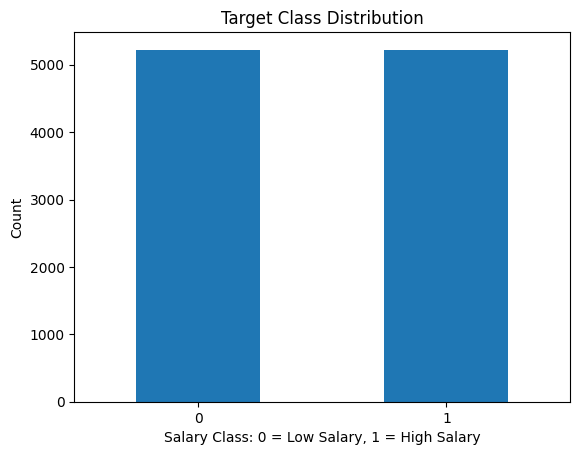

In [8]:
# Step 7: Visualize target class distribution
# This checks whether the classification target is balanced.

df["salary_class"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Salary Class: 0 = Low Salary, 1 = High Salary")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

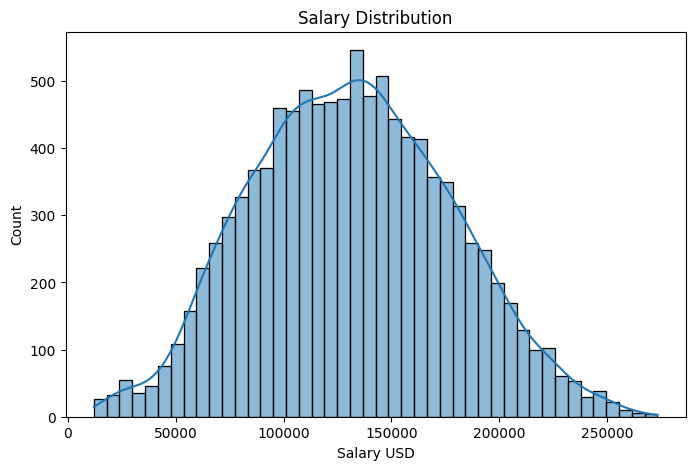

In [16]:
# Step 8: Visualize salary distribution
# This helps understand the original salary range before converting it into classes.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8, 5))
sns.histplot(df['salary_usd'], kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary USD')
plt.ylabel('Count')
plt.show()

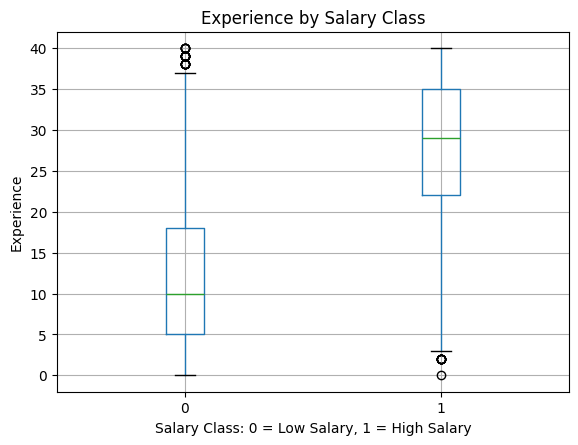

In [10]:
# Step 9: Visualize experience distribution by salary class
# This helps check whether experience may be related to high/low salary.

df.boxplot(column="experience", by="salary_class")
plt.title("Experience by Salary Class")
plt.suptitle("")
plt.xlabel("Salary Class: 0 = Low Salary, 1 = High Salary")
plt.ylabel("Experience")
plt.show()

In [11]:
# Step 10: Prepare features and target
# We remove salary_usd because it was used to create salary_class.
# We also remove salary_class from features because it is the target.

X = df.drop(columns=["salary_usd", "salary_class"])
y = df["salary_class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10443, 6)
Target shape: (10443,)


In [12]:
# Step 11: Split data into Train, Validation, and Test sets
# First split: 70% train and 30% temporary
# Second split: temporary data into 15% validation and 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train shape: (7310, 6)
Validation shape: (1566, 6)
Test shape: (1567, 6)


In [13]:
# Step 12: Build preprocessing pipeline
# KNN is distance-based, so scaling numeric features is very important.
# Missing numeric values are filled using median.
# Missing categorical values are filled using most frequent value.
# Categorical features are encoded using One-Hot Encoding.

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['experience']
Categorical features: ['country', 'education', 'languages', 'frameworks', 'company_size']


In [14]:
# Step 13: Create baseline KNN pipeline
# This pipeline first preprocesses the data, then trains a KNN classifier.

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

valid_pred = knn_pipeline.predict(X_valid)
valid_proba = knn_pipeline.predict_proba(X_valid)[:, 1]

print("Baseline Validation Accuracy:", accuracy_score(y_valid, valid_pred))
print("Baseline Validation F1-score:", f1_score(y_valid, valid_pred))
print("Baseline Validation AUC:", roc_auc_score(y_valid, valid_proba))

Baseline Validation Accuracy: 0.8607918263090677
Baseline Validation F1-score: 0.86375
Baseline Validation AUC: 0.9295860796719562


In [15]:
# Step 14: Hyperparameter tuning using GridSearchCV
# We tune:
# - n_neighbors: number of neighbors / k value
# - weights: uniform or distance
# - metric: euclidean, manhattan, or minkowski

param_grid = {
    "model__n_neighbors": list(range(3, 32, 2)),
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters:
{'model__metric': 'euclidean', 'model__n_neighbors': 25, 'model__weights': 'uniform'}

Best CV F1-score:
0.8867356493080243


In [17]:
# Step 15: Evaluate the best model on validation set
# This checks whether the tuned model performs better before final test evaluation.

best_model = grid_search.best_estimator_

valid_pred = best_model.predict(X_valid)
valid_proba = best_model.predict_proba(X_valid)[:, 1]

print("Validation Accuracy:", accuracy_score(y_valid, valid_pred))
print("Validation Precision:", precision_score(y_valid, valid_pred))
print("Validation Recall:", recall_score(y_valid, valid_pred))
print("Validation F1-score:", f1_score(y_valid, valid_pred))
print("Validation AUC:", roc_auc_score(y_valid, valid_proba))

print("\nValidation Classification Report:")
print(classification_report(y_valid, valid_pred))

Validation Accuracy: 0.8850574712643678
Validation Precision: 0.8717632552404438
Validation Recall: 0.9029374201787995
Validation F1-score: 0.8870765370138017
Validation AUC: 0.9561531849372603

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       783
           1       0.87      0.90      0.89       783

    accuracy                           0.89      1566
   macro avg       0.89      0.89      0.89      1566
weighted avg       0.89      0.89      0.89      1566



In [18]:
# Step 16: Final evaluation on test set
# Test data is used only at the end to estimate final model performance.

test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)
auc = roc_auc_score(y_test, test_proba)

print("Final Test Evaluation Metrics")
print("-----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("AUC      :", auc)

print("\nTest Classification Report:")
print(classification_report(y_test, test_pred))

Final Test Evaluation Metrics
-----------------------------
Accuracy : 0.8627951499680919
Precision: 0.8578616352201258
Recall   : 0.8698979591836735
F1-score : 0.863837872070931
AUC      : 0.9471323011963406

Test Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       783
           1       0.86      0.87      0.86       784

    accuracy                           0.86      1567
   macro avg       0.86      0.86      0.86      1567
weighted avg       0.86      0.86      0.86      1567



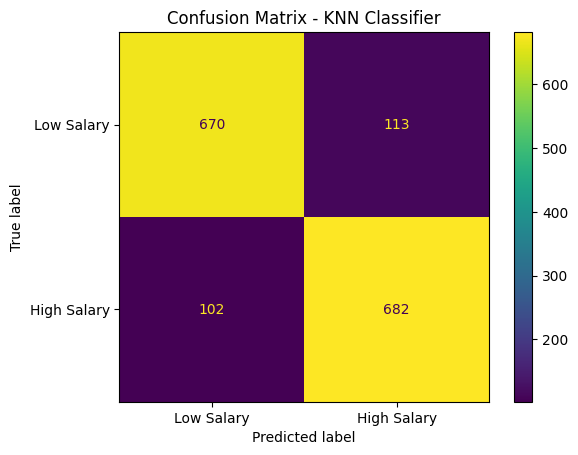

In [19]:
# Step 17: Confusion Matrix heatmap
# This shows True Positives, True Negatives, False Positives, and False Negatives.

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Salary", "High Salary"]
)

disp.plot()
plt.title("Confusion Matrix - KNN Classifier")
plt.show()

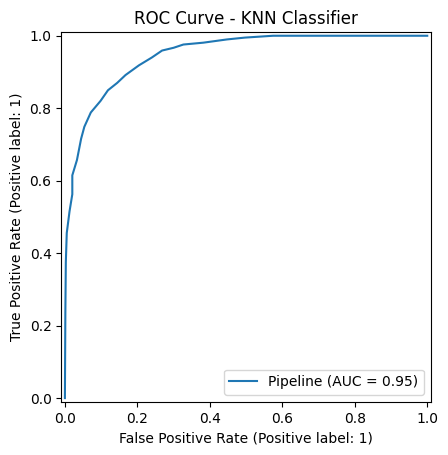

In [23]:
# Step 18: ROC Curve
# ROC curve shows the trade-off between True Positive Rate and False Positive Rate.
# AUC summarizes the ROC performance.

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - KNN Classifier")
plt.show()

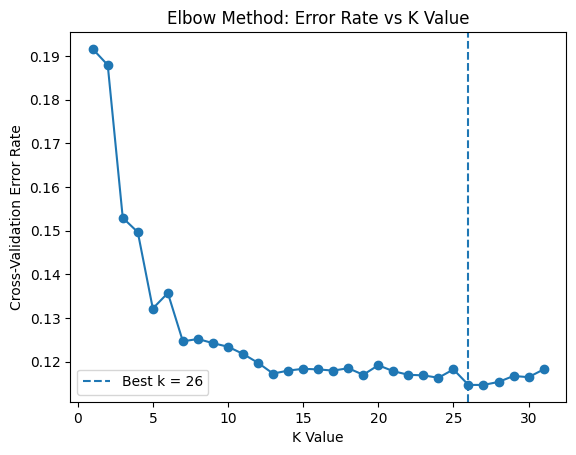

Best k from elbow method: 26


In [24]:
# Step 19: Elbow Method plot for different K values
# We calculate cross-validation error rate for each k.
# Lower error means better performance.

k_values = list(range(1, 32))
error_rates = []

for k in k_values:
    temp_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=k,
            weights=grid_search.best_params_["model__weights"],
            metric=grid_search.best_params_["model__metric"]
        ))
    ])

    scores = cross_val_score(
        temp_model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    error_rates.append(1 - scores.mean())

best_k_from_elbow = k_values[np.argmin(error_rates)]

plt.plot(k_values, error_rates, marker="o")
plt.axvline(best_k_from_elbow, linestyle="--", label=f"Best k = {best_k_from_elbow}")
plt.title("Elbow Method: Error Rate vs K Value")
plt.xlabel("K Value")
plt.ylabel("Cross-Validation Error Rate")
plt.legend()
plt.show()

print("Best k from elbow method:", best_k_from_elbow)

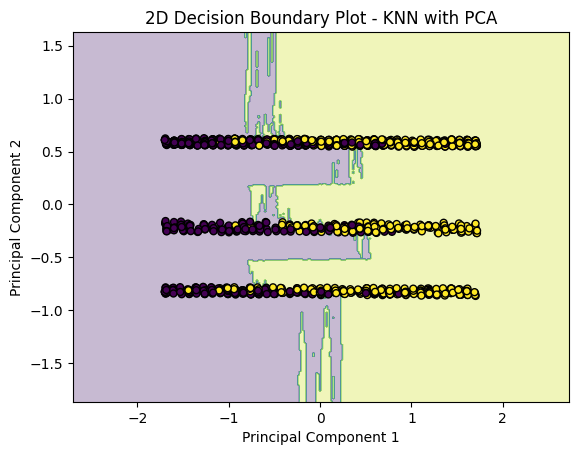

In [25]:
# Step 20: 2D Decision Boundary Plot using PCA
# Since the dataset has many encoded features, we reduce features to 2D using PCA.
# Then we train a KNN model on the 2D data only for visualization.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense array for PCA
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_2d = pca.fit_transform(X_train_processed)
X_test_2d = pca.transform(X_test_processed)

knn_2d = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_["model__n_neighbors"],
    weights=grid_search.best_params_["model__weights"],
    metric=grid_search.best_params_["model__metric"]
)

knn_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolor="k", s=25)
plt.title("2D Decision Boundary Plot - KNN with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [26]:
# Step 21: Save final evaluation metrics into a DataFrame
# This table can be used in the assignment report or GitHub README.

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Score": [accuracy, precision, recall, f1, auc]
})

metrics_df

,Metric,Score
0,Accuracy,0.862795
1,Precision,0.857862
2,Recall,0.869898
3,F1-score,0.863838
4,AUC,0.947132


In [ ]:
##This project implements a K-Nearest Neighbors (KNN) classifier using a salary dataset. The workflow includes data loading, preprocessing, train-test splitting, KNN model training, hyperparameter tuning, and performance evaluation.

##Missing values are handled using imputation, categorical features are encoded using One-Hot Encoding, and numerical features are standardized using StandardScaler. GridSearchCV is used to find the best k value, weights, and distance metric.

##The final model is evaluated using accuracy, precision, recall, F1-score, AUC, confusion matrix, ROC curve, elbow method plot, and a 2D decision boundary plot.

##The results show that KNN performs well after proper preprocessing and hyperparameter tuning.
